In [154]:
import alphastats

In [155]:
diann_data = alphastats.DIANNLoader(file="diann_output.pg_matrix.tsv")

In [164]:
dataset = alphastats.DataSet(
    loader = diann_data, 
    metadata_path="metadata_alphastats.xlsx", 
    sample_column="sample_id"
)

DataSet has been created.
Attributes of the DataSet can be accessed using: 
DataSet.rawinput:	 Raw Protein data.
DataSet.mat:		Processed data matrix with ProteinIDs/ProteinGroups as columns and samples as rows. All computations are performed on this matrix.
DataSet.metadata:	Metadata for the samples in the matrix. Metadata will be matched with DataSet.mat when needed (for instance Volcano Plot).


In [165]:
dataset.metadata


,sample_id,biological_id,grouping
0,2ul_CG_3.mzML,vcam1-ip-r1,vcam1-ip
1,2ul_CG_4.mzML,vcam1-igg-r1,vcam1-igg
2,2ul_CG_5.mzML,vcam1-ip-r2,vcam1-ip
3,2ul_CG_6.mzML,vcam1-igg-r2,vcam1-igg
4,2ul_CG_7.mzML,vcam1-ip-r3,vcam1-ip
5,2ul_CG_8.mzML,vcam1-igg-r3,vcam1-igg
6,2ul_CG_9.mzML,vcam1-ip-r4,vcam1-ip
7,2ul_CG_10.mzML,vcam1-igg-r4,vcam1-igg


In [166]:
dataset.preprocess(
    remove_contaminations=True,
    normalization = "zscore",
    imputation = "knn"
)

Data has been log2-transformed.


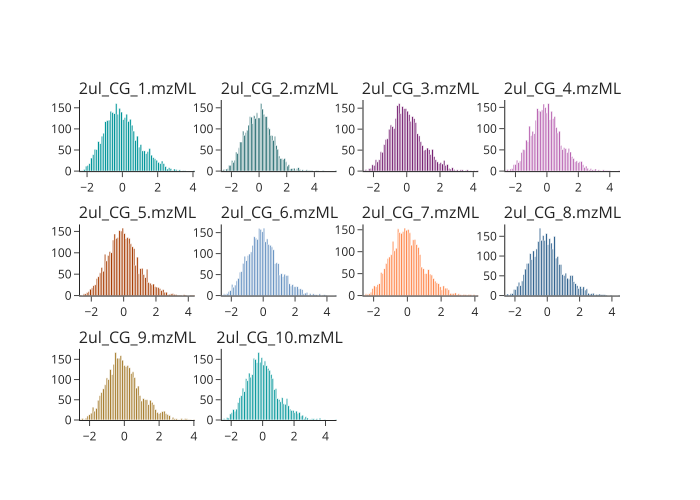

In [162]:
plot = dataset.plot_samplehistograms()
plot.show(renderer = "svg")

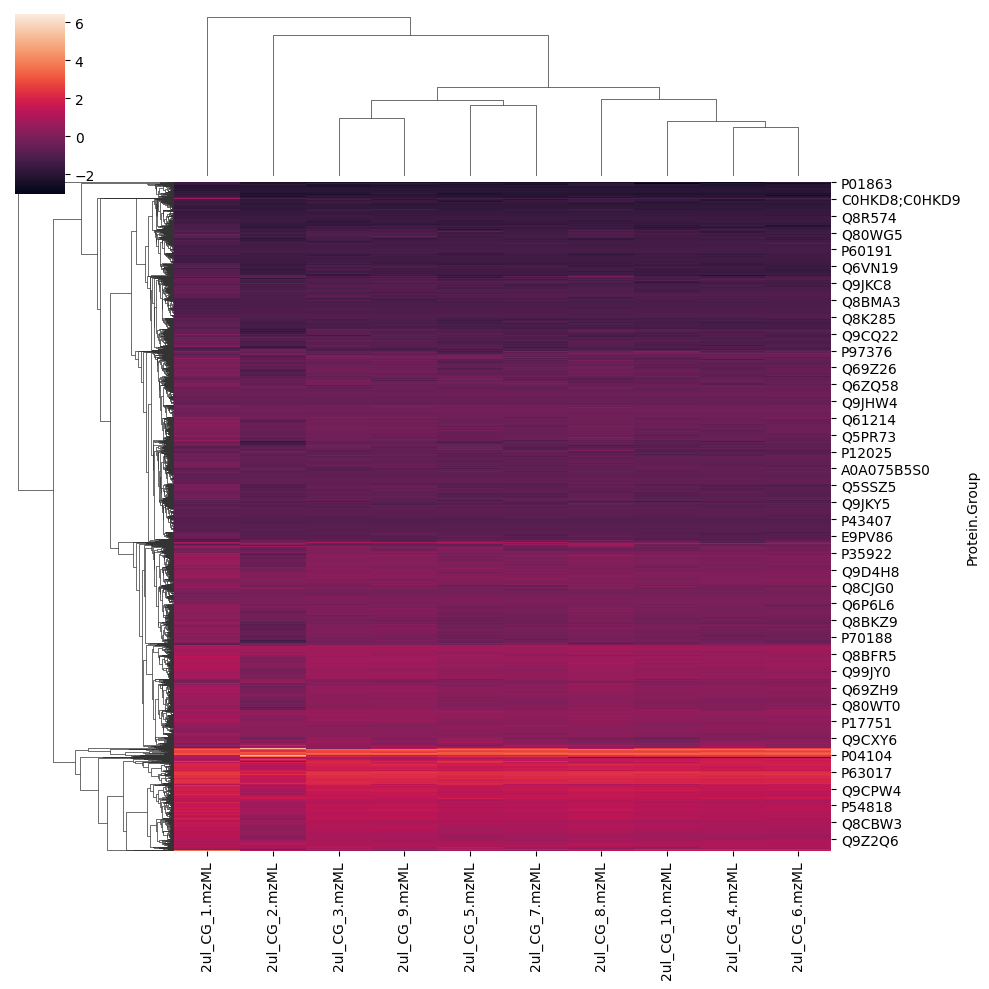

In [170]:
plot = dataset.plot_clustermap()


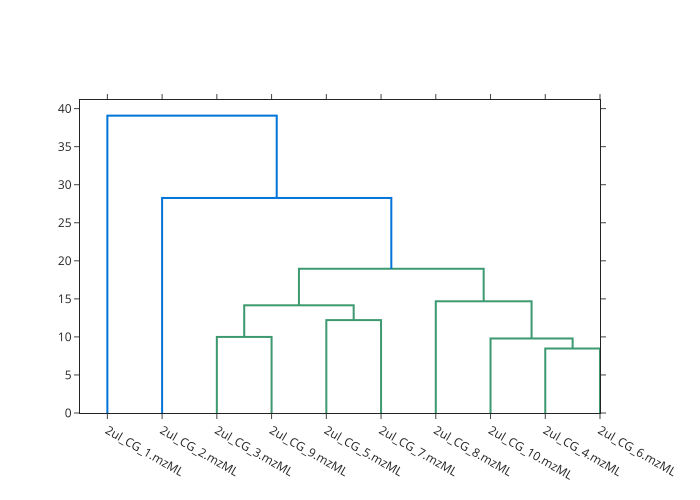

In [171]:
plot = dataset.plot_dendrogram()
plot.show(renderer = "svg")

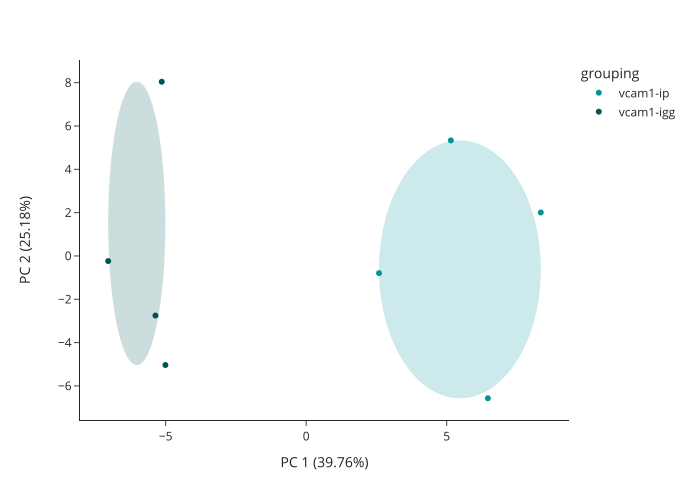

In [167]:
plot = dataset.plot_pca(group = "grouping", circle = True)
plot.show(renderer = "svg")

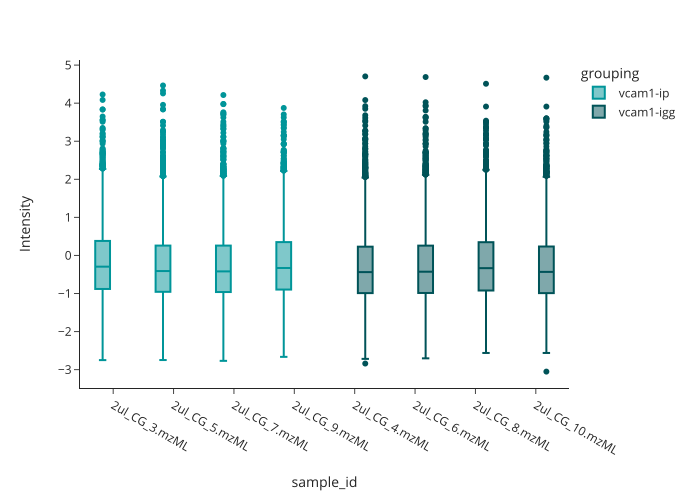

In [172]:
plot = dataset.plot_sampledistribution(color = "grouping", method="box", log_scale=False)
plot.show(renderer = "svg")

Calculating Students t-test...


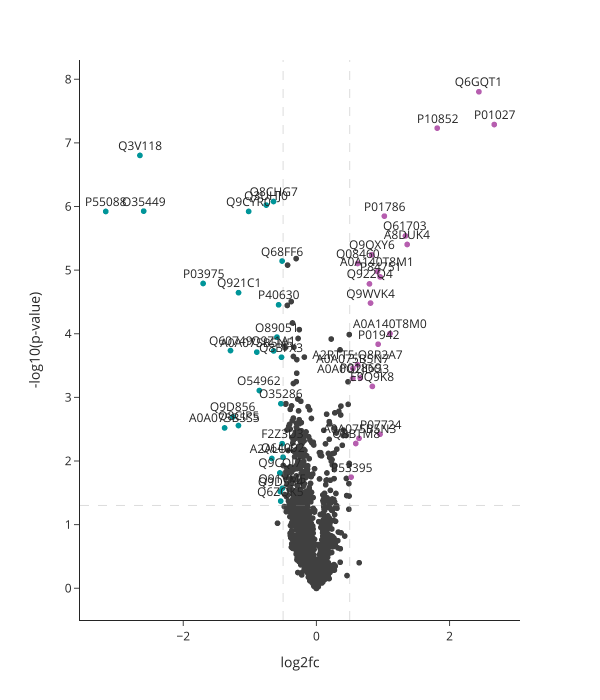

In [179]:
plot = dataset.plot_volcano(column = "grouping", 
                            group1 = "vcam1-igg", 
                            group2 = "vcam1-ip", 
                            method = "ttest", 
                            labels = True,
                            min_fc=0.5,
                            alpha=0.05)
plot.show(renderer = "svg")

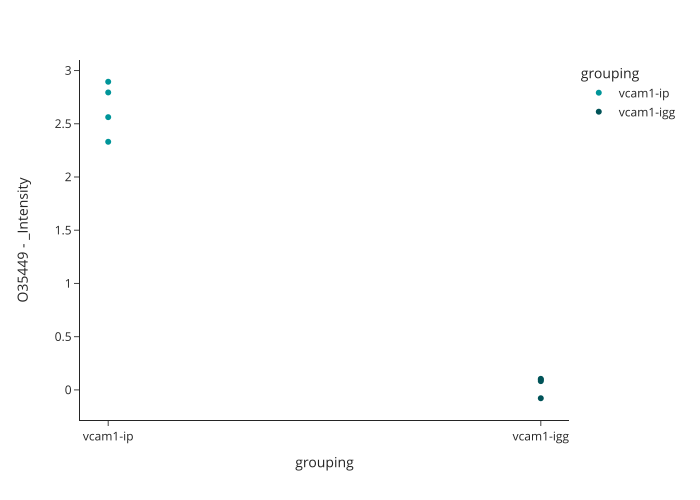

In [173]:
plot = dataset.plot_intensity(protein_id="O35449", group = "grouping", method = "scatter")
plot.show(renderer = "svg")